# **Complete repository step-by-step diagnostics. (Optimization Modules)**

In [96]:
# Add in validation utilities for testing and diagnostics.

from typing import Any, Callable, Optional
from IPython.display import Image
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

## Rehydrate the main setup code to ensure all modules are loaded for diagnostics

In [97]:
"""
# Iligan City

import yaml
from dotenv import load_dotenv

from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()

with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

CACHE_DIR = cfg["global"]["cache_dir"]

print("[OPTIMIZATION SETUP] Loading CityGraph from cache...")
city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg.get("landmarks"),
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    cache_dir=CACHE_DIR,
    cache_prefix=city_graph_cfg["cache_prefix"]
)

print("[OPTIMIZATION SETUP] Initializing Direct Demand Sampler...")
ddm_params = cfg["ddm"].copy()
ddm_params["cache_dir"] = CACHE_DIR

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**ddm_params),
    verbose=False
)

print("[OPTIMIZATION SETUP] Initializing Route Generator...")
generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=False
)

print("[OPTIMIZATION SETUP] Building TravelGraph with fresh routes...")
num_routes = cfg.get("simulation", {}).get("num_routes", 5)
tg = TravelGraph(
    cg=city,
    config=cfg["travel_graph"],
    route_generator=generator,
    n_routes=num_routes,
    n_points=5
)
routes = tg.routes

print(f"[OPTIMIZATION SETUP] Ready. Base modules, {len(routes)} fresh routes, and TravelGraph loaded.")
"""

'\n# Iligan City\n\nimport yaml\nfrom dotenv import load_dotenv\n\nfrom utils.city_graph import CityGraph\nfrom utils.direct_demand_sampler import DirectDemandSampler, DDMConfig\nfrom utils.route import RouteGenerator\nfrom utils.travel_graph import TravelGraph\n\nload_dotenv()\n\nwith open(\'configs/iligan_configs.yaml\', \'r\') as f:\n    cfg = yaml.safe_load(f)\n\nCACHE_DIR = cfg["global"]["cache_dir"]\n\nprint("[OPTIMIZATION SETUP] Loading CityGraph from cache...")\ncity_graph_cfg = cfg["city_graph"]\ncity = CityGraph(\n    bbox=tuple(city_graph_cfg["bbox"]),\n    name=city_graph_cfg["name"],\n    landmarks=city_graph_cfg.get("landmarks"),\n    pbf_path=city_graph_cfg["pbf_path"],\n    use_api=False,\n    cache_dir=CACHE_DIR,\n    cache_prefix=city_graph_cfg["cache_prefix"]\n)\n\nprint("[OPTIMIZATION SETUP] Initializing Direct Demand Sampler...")\nddm_params = cfg["ddm"].copy()\nddm_params["cache_dir"] = CACHE_DIR\n\nsampler = DirectDemandSampler(\n    city=city,\n    config=DDMCon

In [98]:
# Toy City

from utils.toy_city import toy_setup_from_yaml
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

print("[OPTIMIZATION SETUP] Loading toy city...")
city, sampler, cfg = toy_setup_from_yaml('configs/toy_city_configs.yaml', verbose=True)

print("[OPTIMIZATION SETUP] Initializing Route Generator...")
generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=False
)

print("[OPTIMIZATION SETUP] Building TravelGraph with fresh routes...")
num_routes = cfg.get("simulation", {}).get("num_routes", 5)
tg = TravelGraph(
    cg=city,
    config=cfg["travel_graph"],
    route_generator=generator,
    n_routes=num_routes,
    n_points=5
)
routes = tg.routes

print(f"[OPTIMIZATION SETUP] Ready. Base modules, {len(routes)} fresh routes, and TravelGraph loaded.")


[OPTIMIZATION SETUP] Loading toy city...

[TOY CITY] Building 50×50 grid…
CityGraph(ToyCity(50×50)) | Nodes: 2500 | Edges: 9800 (Drivable: 9800) | Landmarks: []
[TOY DDM] Built demand surface over 2500 nodes (2500 drivable) using 11 hotspots.
  · [Downtown Public Market]  weight=15.0  nearest_node_prob=0.00076
  · [University Belt]  weight=12.0  nearest_node_prob=0.00061
  · [North Regional Terminal]  weight=10.0  nearest_node_prob=0.00050
  · [South City Terminal]  weight=10.0  nearest_node_prob=0.00050
  · [Mega Mall Complex]  weight=9.0  nearest_node_prob=0.00045
  · [BPO / Tech Park]  weight=8.0  nearest_node_prob=0.00040
  · [City General Hospital]  weight=7.0  nearest_node_prob=0.00035
  · [Heavy Industrial Zone]  weight=6.0  nearest_node_prob=0.00030
  · [Suburban Residential (East)]  weight=3.0  nearest_node_prob=0.00015
  · [Suburban Residential (Northeast)]  weight=2.0  nearest_node_prob=0.00010
  · [Suburban Residential (Southwest)]  weight=2.5  nearest_node_prob=0.00013
  Demand contrast (max/min prob): 7.5×


[OPTIMIZATION SETUP] Initializing Route Generator...

[OPTIMIZATION SETUP] Building TravelGraph with fresh routes...

[OPTIMIZATION SETUP] Ready. Base modules, 5 fresh routes, and TravelGraph loaded.

## **Pheromone** (in pheromone.py, using the new SimulationEvaluator in simulation.py)

[VALIDATED] Assemble Baseline Simulation: Executed successfully.

[VALIDATED] Evaluate Baseline Route System: Executed successfully.

[RESULTS] Fitness Score:          10788118.71

[RESULTS] Completed Journeys:     354

[RESULTS] Incomplete Journeys:    691

[VALIDATED] Initialize PheromoneMatrix: Executed successfully.

[VISUALIZATION] Rendering Route Infrastructure...

[VISUALIZATION] Rendering Pheromone Demand Spectrum...

[VALIDATED] Draw Pheromone Matrix: Executed successfully.

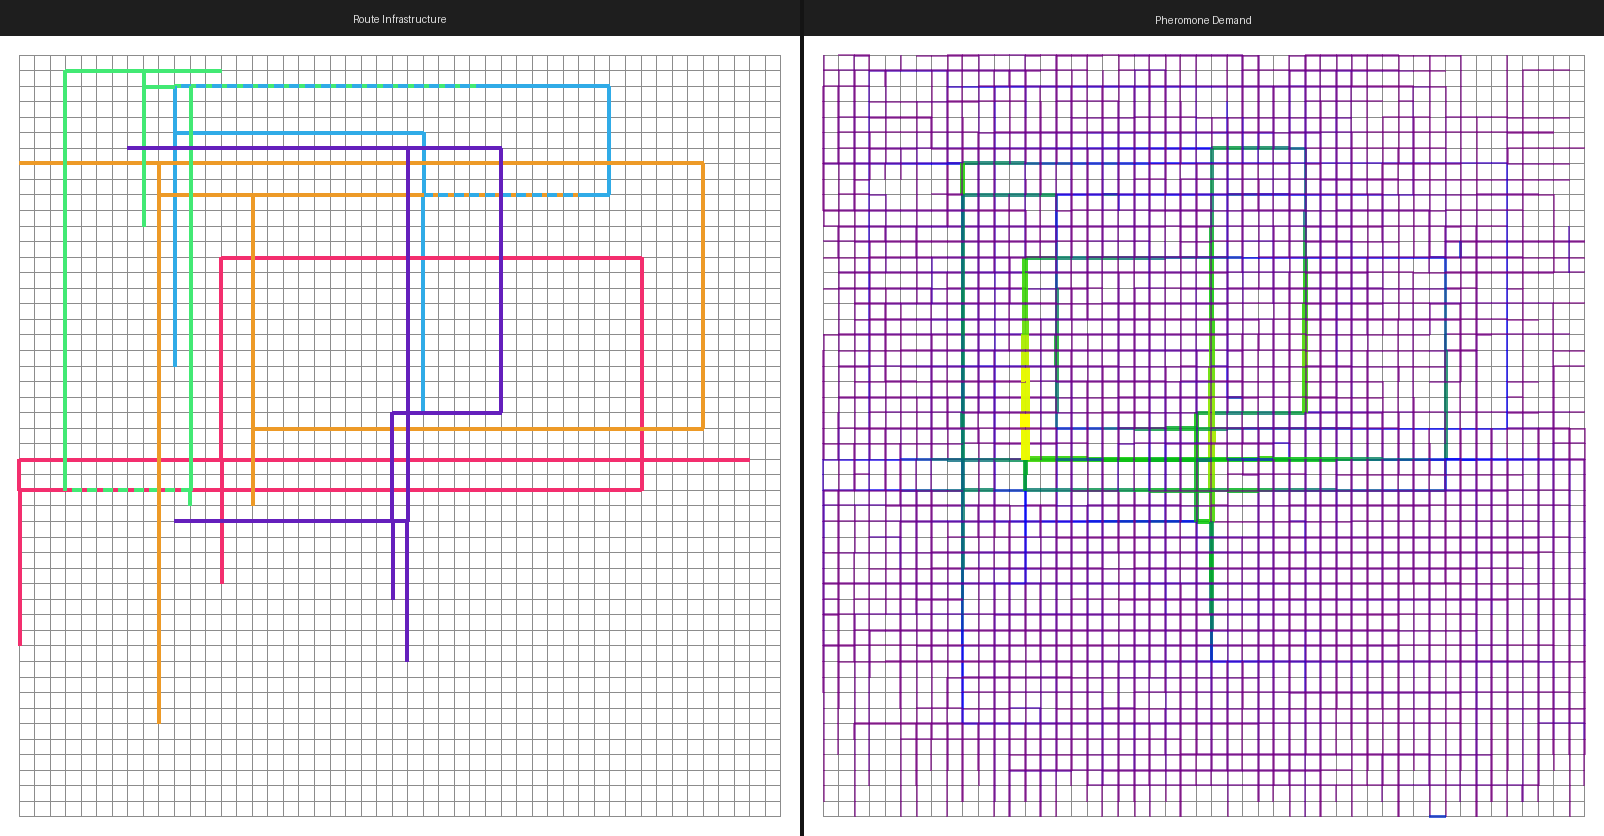

In [99]:
from utils.simulation import Simulation
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.passenger_generator import PassengerGenerator
from utils.pheromone import PheromoneMatrix
from utils.route import RouteSystem
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

sim_cfg = cfg.get("simulation", {})
jeep_speed       = sim_cfg.get("jeep_speed_kmh", 40.0)
jeep_capacity    = sim_cfg.get("jeep_capacity", 16)
weight_tol       = sim_cfg.get("weight_tolerance", 50.0)
seconds_per_tick = sim_cfg.get("seconds_per_tick", 1)
total_jeeps      = sim_cfg.get("total_allocatable_jeeps", 25)
jeeps_per_route  = max(1, total_jeeps // len(routes))

# 1. Build and run the simulation directly so result.jeep_system stays intact.
jeeps = []
for route in routes:
    for _ in range(jeeps_per_route):
        start_coord = (route.path[0].start.lon, route.path[0].start.lat)
        jeeps.append(Jeep(route, curr_pos=start_coord, speed=jeep_speed,
                          max_capacity=jeep_capacity, seconds_per_tick=seconds_per_tick))

jeep_system = JeepSystem(
    jeeps=jeeps,
    routes=routes,
    weight_tolerance=weight_tol,
    equidistant_spawn=True
)

passenger_generator = PassengerGenerator(
    tg=tg,
    sampler=sampler,
    rate_per_hour=sim_cfg.get("spawn_rate_per_hour", 40.0),
    stdev=sim_cfg.get("spawn_stdev", 5.0),
    speed=sim_cfg.get("passenger_speed_kmh", 5.0),
    seconds_per_tick=seconds_per_tick
)

sim = validate_call(
    "Assemble Baseline Simulation",
    True,
    Simulation,
    city_query=city.name,
    bounds=city.get_bounds(),
    jeep_system=jeep_system,
    passenger_generator=passenger_generator,
    max_ticks=sim_cfg.get("num_ticks", 300),
    beta_penalty=cfg.get("BETA_PENALTY", 2.0),
    alpha_std_penalty=cfg.get("ALPHA_STD_PENALTY", 0.5),
    config=cfg
)

result = validate_call("Evaluate Baseline Route System", True, sim.run)

if result:
    print(f"[RESULTS] Fitness Score:          {result.fitness_score:.2f}")
    print(f"[RESULTS] Completed Journeys:     {result.metrics['completed_count']}")
    print(f"[RESULTS] Incomplete Journeys:    {result.metrics['incomplete_count']}")

    # 2. Extract active edges and initialize pheromones.
    active_network_edges = set()
    for path, _ in result.recorded_paths:
        if path:
            active_network_edges.update(path)
    for route in routes:
        active_network_edges.update(route.path)

    pheromones = validate_call(
        "Initialize PheromoneMatrix",
        True,
        PheromoneMatrix,
        all_edges=active_network_edges,
        config=cfg,
        sim_result=result
    )

    # 3. Render both maps independently on clean base copies.
    context  = city.get_bounds()
    SIZE     = 800
    base_map = city.draw(size=SIZE)

    # — Left panel: route infrastructure —
    rs = RouteSystem()
    for r in routes:
        rs.add_route(r)

    print("[VISUALIZATION] Rendering Route Infrastructure...")
    route_map = rs.draw(context, base_map.copy(), line_width=4, dash_length=10)

    # — Right panel: pheromone demand spectrum —
    print("[VISUALIZATION] Rendering Pheromone Demand Spectrum...")
    pheromone_map = validate_call(
        "Draw Pheromone Matrix",
        True,
        pheromones.draw,
        context,
        base_map.copy(),   # fresh base — no routes drawn on top
    )

    # 4. Stitch side-by-side with labels.
    def _label(img: Image.Image, text: str) -> Image.Image:
        """Adds a centered title bar above an image."""
        BAR_H = 36
        out = Image.new("RGB", (img.width, img.height + BAR_H), (30, 30, 30))
        out.paste(img, (0, BAR_H))
        draw = ImageDraw.Draw(out)
        try:
            font = ImageFont.truetype("arial.ttf", 18)
        except IOError:
            font = ImageFont.load_default()
        bbox = draw.textbbox((0, 0), text, font=font)
        tx = (img.width - (bbox[2] - bbox[0])) // 2
        ty = (BAR_H - (bbox[3] - bbox[1])) // 2
        draw.text((tx, ty), text, fill=(220, 220, 220), font=font)
        return out

    if pheromone_map:
        left  = _label(route_map,     "Route Infrastructure")
        right = _label(pheromone_map, "Pheromone Demand")

        panel = Image.new("RGB", (left.width + right.width + 4, max(left.height, right.height)), (20, 20, 20))
        panel.paste(left,  (0, 0))
        panel.paste(right, (left.width + 4, 0))

        display(panel)

## **ExperimentConfig and OptimizationState** (in optimizer_config.py)

In [100]:
from utils.optimizer_config import ExperimentConfig, OptimizationState

yaml_path = 'configs/toy_city_configs.yaml'

config = validate_call("Parse YAML Config", True, ExperimentConfig.from_yaml, yaml_path)

if config:
    assert_true(isinstance(config.max_ticks, int), "max_ticks failed integer cast.")
    assert_true(isinstance(config.p_mutation, float), "p_mutation failed float cast.")
    assert_true(isinstance(config.city_bounds, tuple), "city_bounds failed tuple cast.")
    assert_true(len(config.city_bounds) == 4, "city_bounds tuple length invalid.")
    
    print(f"[TEST] BBox Extracted: {config.city_bounds}")
    print(f"[TEST] Total Fleet Registered: {config.total_allocatable_jeeps}")
    print(f"[TEST] Telemetry Export Path: {config.output_root}")

state = validate_call("Initialize OptimizationState", True, OptimizationState)

if state:
    assert_true(state.generation == 1, "State generation default invalid.")
    assert_true(state.best_fitness == float('inf'), "State fitness default invalid.")

[VALIDATED] Parse YAML Config: Executed successfully.

[TEST] BBox Extracted: (124.2, 8.2, 124.25, 8.25)

[TEST] Total Fleet Registered: 20

[TEST] Telemetry Export Path: outputs/toy_runs

[VALIDATED] Initialize OptimizationState: Executed successfully.

## **AdaptiveController** (in optimizer_adaptive.py)

In [101]:
from utils.optimizer_adaptive import AdaptiveController

base_mut = 0.2
limit = 10
expected_cap = 0.8

adaptive = validate_call("Initialize AdaptiveController", True, AdaptiveController, base_mutation=base_mut, stagnation_limit=limit)

if adaptive:
    # 1. Baseline behavior
    mut_0 = adaptive.update(0)
    assert_true(mut_0 == base_mut, f"Expected baseline {base_mut}, got {mut_0}")
    print(f"[TEST] Stagnation 0 -> Mutation Rate: {mut_0:.2f}")

    # 2. Intermediate scaling
    mut_mid = adaptive.update(limit // 2)
    assert_true(mut_mid > base_mut, "Mutation rate did not scale up during stagnation.")
    print(f"[TEST] Stagnation {limit//2} -> Mutation Rate: {mut_mid:.2f}")

    # 3. Limit behavior (Cap)
    mut_max = adaptive.update(limit)
    assert_true(mut_max == expected_cap, f"Expected hard cap {expected_cap}, got {mut_max}")
    print(f"[TEST] Stagnation {limit} -> Mutation Rate: {mut_max:.2f}")

    # 4. Overshoot behavior
    mut_over = adaptive.update(limit + 5)
    assert_true(mut_over == expected_cap, f"Mutation rate exceeded hard cap, got {mut_over}")
    print(f"[TEST] Stagnation overshoot ({limit + 5}) -> Mutation Rate capped at: {mut_over:.2f}")

    # 5. Reset behavior
    mut_reset = adaptive.update(0)
    assert_true(mut_reset == base_mut, "Mutation rate did not reset on improvement.")
    print("[TEST] Stagnation Reset -> Mutation Rate successfully restored to baseline.")

[VALIDATED] Initialize AdaptiveController: Executed successfully.

[TEST] Stagnation 0 -> Mutation Rate: 0.20

[TEST] Stagnation 5 -> Mutation Rate: 0.35

[TEST] Stagnation 10 -> Mutation Rate: 0.80

[TEST] Stagnation overshoot (15) -> Mutation Rate capped at: 0.80

[TEST] Stagnation Reset -> Mutation Rate successfully restored to baseline.

## **TelemetryEngine** (in optimizer_telemetry.py)

In [102]:
import tempfile
import csv
import json
from pathlib import Path
from utils.optimizer_telemetry import TelemetryEngine

# Mock structure to bypass deep dependencies
class MockNode:
    def __init__(self, lat, lon): self.lat, self.lon = lat, lon
class MockEdge:
    def __init__(self):
        self.start = MockNode(8.2, 124.2)
        self.end = MockNode(8.21, 124.21)
class MockRoute:
    def __init__(self): self.path = [MockEdge()]
class MockPheromones:
    def __init__(self): self.tau = {MockEdge(): 2.5}
    def calculate_demand_service_gaps(self, dummy_sys): return {MockEdge(): 6.0}
class MockChromosome:
    def __init__(self, cost):
        self.uid, self.generation, self.cost = "chrom_001", 1, cost
        self.parents = ["P1", "P2"]
        self.routes, self.pheromones = [MockRoute()], MockPheromones()
        self.allocation = {self.routes[0]: 5}

with tempfile.TemporaryDirectory() as tmpdir:
    run_dir = Path(tmpdir)
    bounds = (0.0, 0.0, 0.0, 0.0)
    
    # Run 1: Initialization
    te1 = validate_call("Initialize Telemetry (Run 1)", True, TelemetryEngine, run_dir, bounds)
    validate_call("Log Generation 1", True, te1.log_generation, 1, 100.0, 150.0, 0.2, 0)
    
    # Run 2: Resume Checkpoint
    te2 = validate_call("Initialize Telemetry (Run 2 Resume)", True, TelemetryEngine, run_dir, bounds)
    validate_call("Log Generation 2", True, te2.log_generation, 2, 90.0, 140.0, 0.2, 0)
    
    # Assert rerunnability: Headers (1) + Run 1 (1) + Run 2 (1) = 3 rows
    with open(run_dir / "history.csv", "r") as f:
        rows = list(csv.reader(f))
        assert_true(len(rows) == 3, "Telemetry failed to append; historical data was overwritten.")
        print("[TEST] Historical append validation passed.")

    # Export validation
    chroms = [MockChromosome(100.0), MockChromosome(120.0)]
    validate_call("Export JSON Snapshot", True, te1.export_json_snapshot, 2, 90.0, 110.0, chroms)
    
    json_path = run_dir / "snapshots" / "network_state_gen_2.json"
    assert_true(json_path.exists(), "JSON snapshot was not generated.")
    
    with open(json_path, "r") as f:
        payload = json.load(f)
        assert_true(payload["metadata"]["best_cost"] == 90.0, "JSON payload data mismatch.")
        print("[TEST] JSON structure and API bridging successfully validated.")

[VALIDATED] Initialize Telemetry (Run 1): Executed successfully.

[VALIDATED] Log Generation 1: Executed successfully.

[VALIDATED] Initialize Telemetry (Run 2 Resume): Executed successfully.

[VALIDATED] Log Generation 2: Executed successfully.

[TEST] Historical append validation passed.

[VALIDATED] Export JSON Snapshot: Executed successfully.

[TEST] JSON structure and API bridging successfully validated.

## **OptimizerBuilder and StatePreservtionEnging** (in optimizer_orchestrator_io.py)

In [103]:
import tempfile
import yaml
from pathlib import Path
from utils.optimizer_orchestrator_io import OptimizerBuilder, StatePreservationEngine
from utils.optimizer_config import OptimizationState

yaml_path = 'configs/toy_city_configs.yaml'

with tempfile.TemporaryDirectory() as tmpdir:
    tmp_root = Path(tmpdir)
    
    # Reroute test output to the temporary directory
    with open(yaml_path, 'r') as f:
        test_cfg = yaml.safe_load(f)
    test_cfg["optimization"]["output_root"] = str(tmp_root)
    
    temp_yaml = tmp_root / "test_configs.yaml"
    with open(temp_yaml, 'w') as f:
        yaml.dump(test_cfg, f)

    # 1. Build Initialization
    build_result = validate_call("Build New Run", True, OptimizerBuilder.build_new_run, temp_yaml)
    if build_result:
        config, run_dir = build_result
        assert_true(run_dir.exists(), "Run directory was not created.")
        assert_true((run_dir / "configs.yaml").exists(), "Config file was not copied to run directory.")
        print("[TEST] Build logic successfully instantiated isolated environment.")

    # 2. State Serialization
    engine = validate_call("Initialize Preservation Engine", True, StatePreservationEngine, run_dir)
    if engine:
        dummy_state_1 = OptimizationState(generation=1, best_fitness=500.0)
        dummy_state_2 = OptimizationState(generation=2, best_fitness=450.0)
        
        validate_call("Save Checkpoint Gen 1", True, engine.save_state, dummy_state_1)
        validate_call("Save Checkpoint Gen 2", True, engine.save_state, dummy_state_2)
        
        checkpoint_path = engine.checkpoints_dir / "state_gen_2.pkl"
        assert_true(checkpoint_path.exists(), "State serialization failed.")
        print("[TEST] State serialization and atomic write sequence passed.")

    # 3. Environment Reconstruction
    resume_result = validate_call("Resume Run", True, OptimizerBuilder.resume_run, run_dir)
    if resume_result:
        resumed_config, resumed_state, resumed_dir = resume_result
        assert_true(resumed_dir == run_dir, "Resumed directory string mapping failed.")
        assert_true(resumed_state.generation == 2, f"Failed to load the latest generation. Loaded: {resumed_state.generation}")
        assert_true(resumed_state.best_fitness == 450.0, "State fitness payload corrupted during deserialization.")
        print("[TEST] Orchestrator resume protocol and config recovery successfully executed.")

[VALIDATED] Build New Run: Executed successfully.

[TEST] Build logic successfully instantiated isolated environment.

[VALIDATED] Initialize Preservation Engine: Executed successfully.

[VALIDATED] Save Checkpoint Gen 1: Executed successfully.

[VALIDATED] Save Checkpoint Gen 2: Executed successfully.

[TEST] State serialization and atomic write sequence passed.

[VALIDATED] Resume Run: Executed successfully.

[TEST] Orchestrator resume protocol and config recovery successfully executed.

## **ACOLocalSearch** and mutation methods (in local_search.py)

In [ ]:
# ==============================================================================
# ACO Local Search Diagnostics - Step 1: Initialization & Validation
# ==============================================================================
import random
import math
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

from utils.toy_city import toy_setup_from_yaml
from utils.route import RouteGenerator, RouteSystem, Route
from utils.travel_graph import TravelGraph
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.passenger_generator import PassengerGenerator
from utils.simulation import Simulation, StaticSurrogateEvaluator
from utils.pheromone import PheromoneMatrix
from utils.local_search import ACOLocalSearch

# pwede rani kwaon
try:
    engine = ACOLocalSearch(cg=city, p_local=1.0, base_window_size=15)
    print("Success:", engine)
except Exception as e:
    print(f"{type(e).__name__}: {e}")
    
print("[DIAGNOSTIC SETUP] Re-hydrating toy network environment...")

# Initialize generator, engine, and surrogate utilizing the custom validate_call helper
generator = RouteGenerator(city_graph=city, sampler=sampler, verbose=False)

# Changed from p_local to p_attraction, p_repulsion, and p_pruning.

""" engine = validate_call(
    "Initialize ACOLocalSearch Engine",
    True,
    ACOLocalSearch,
    cg=city,
    p_local=1.0,
    base_window_size=15
) """

engine = validate_call(
    "Initialize ACOLocalSearch Engine",
    True,
    ACOLocalSearch,
    cg=city,
    p_attraction=1.0,
    p_repulsion=1.0,
    p_pruning=1.0,
    base_window_size=15
)

if engine is None:
    raise RuntimeError("ACOLocalSearch failed to initialize. Fix the error above before continuing.")

surrogate = validate_call(
    "Initialize StaticSurrogateEvaluator",
    True,
    StaticSurrogateEvaluator,
    config=cfg,
    city_graph=city,
    demand_sampler=sampler,
    num_samples=100
)

print("[DIAGNOSTIC SETUP] Local search diagnostics tools successfully initialized.")


TypeError: ACOLocalSearch.__init__() got an unexpected keyword argument 'p_local'

[DIAGNOSTIC SETUP] Re-hydrating toy network environment...

[VALIDATED] Initialize ACOLocalSearch Engine: Executed successfully.

[VALIDATED] Initialize StaticSurrogateEvaluator: Executed successfully.

[DIAGNOSTIC SETUP] Local search diagnostics tools successfully initialized.

In [ ]:
# ==============================================================================
# ACO Local Search Diagnostics - Step 2: Evaluation & Light-Mode Drawing Helpers
# ==============================================================================

def run_actual_simulation(routes, city, sampler, cfg, ticks=150):
    sim_cfg = cfg.get("simulation", {})
    tg = TravelGraph(cg=city, config=cfg["travel_graph"], routes=routes)
    
    jeeps = []
    total_jeeps = sim_cfg.get("total_allocatable_jeeps", 20)
    jeep_speed_kmh = sim_cfg.get("jeep_speed_kmh", 20.0) 
    jeep_capacity = sim_cfg.get("jeep_capacity", 16)
    weight_tol = sim_cfg.get("weight_tolerance", 50.0)
    seconds_per_tick = sim_cfg.get("seconds_per_tick", 30)

    jeeps_per_route = max(1, total_jeeps // len(routes))

    for route in routes:
        for _ in range(jeeps_per_route):
            start_coord = (route.path[0].start.lon, route.path[0].start.lat)
            jeeps.append(Jeep(
                route, 
                curr_pos=start_coord, 
                speed=jeep_speed_kmh, 
                max_capacity=jeep_capacity, 
                seconds_per_tick=seconds_per_tick
            ))
            
    jeep_system = JeepSystem(
        jeeps=jeeps, 
        routes=routes, 
        weight_tolerance=weight_tol,
        equidistant_spawn=True
    )
    
    passenger_generator = PassengerGenerator(
        tg=tg,
        sampler=sampler,
        rate_per_hour=sim_cfg.get("spawn_rate_per_hour", 120.0),
        stdev=sim_cfg.get("spawn_stdev", 10.0),
        speed=sim_cfg.get("passenger_speed_kmh", 4.5),
        seconds_per_tick=seconds_per_tick
    )
    
    sim = Simulation(
        city_query=city.name,
        bounds=city.get_bounds(),
        jeep_system=jeep_system,
        passenger_generator=passenger_generator,
        max_ticks=ticks,
        beta_penalty=cfg.get("BETA_PENALTY", 2.0),
        alpha_std_penalty=cfg.get("ALPHA_STD_PENALTY", 0.5),
        config=cfg
    )
    
    return sim.run()

def draw_light_city(city, size=400, only_drivable=True):
    context = city.get_bounds()
    image = Image.new("RGB", (size, size), "#f8fafc")
    for edge in city.graph:
        if only_drivable and not edge.is_drivable:
            continue
        color = "#a0aec0" if edge.is_drivable else "#cbd5e1"
        edge.draw(context, image, color=color, width=1)
    return image

def draw_panel_with_labels(panel_img, title, bottom_text, font_bold, font_body):
    img = panel_img.convert("RGBA")
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d_overlay = ImageDraw.Draw(overlay)
    
    # Premium Light Banners
    d_overlay.rectangle([0, 0, img.width, 30], fill=(255, 255, 255, 235))
    d_overlay.rectangle([0, img.height - 35, img.width, img.height], fill=(255, 255, 255, 235))
    
    # Subtle separators
    d_overlay.line([(0, 30), (img.width, 30)], fill=(226, 232, 240, 255), width=1)
    d_overlay.line([(0, img.height - 35), (img.width, img.height - 35)], fill=(226, 232, 240, 255), width=1)
    
    img = Image.alpha_composite(img, overlay)
    draw = ImageDraw.Draw(img)
    draw.text((img.width // 2, 15), title, fill="#0f172a", font=font_bold, anchor="mm")
    draw.text((img.width // 2, img.height - 17), bottom_text, fill="#475569", font=font_body, anchor="mm")
    
    return img.convert("RGB")

print("[DIAGNOSTIC HELPERS] Evaluation and premium light mode rendering tools prepared.")


[DIAGNOSTIC HELPERS] Evaluation and premium light mode rendering tools prepared.

In [ ]:
# ==============================================================================
# ACO Local Search Diagnostics - Step 3: Diagnostic Pipeline Execution (Showcases)
# ==============================================================================

# Lists to store final rendered panel images
showcase_panels = []

# Try loading premium fonts
try:
    font_bold = ImageFont.truetype("segoeuib.ttf", 15)
    font_body = ImageFont.truetype("segoeui.ttf", 13)
except IOError:
    try:
        font_bold = ImageFont.truetype("arial.ttf", 15)
        font_body = ImageFont.truetype("arial.ttf", 13)
    except IOError:
        font_bold = ImageFont.load_default()
        font_body = ImageFont.load_default()

CELL_SIZE = 400
context = city.get_bounds()

# Define the operators to showcase sequentially
operators = [
    {"name": "Attraction", "strategy": "attraction"},
    {"name": "Repulsion", "strategy": "repulsion"},
    {"name": "Pruning", "strategy": "pruning"}
]

for op_info in operators:
    op_name = op_info["name"]
    op_type = op_info["strategy"]
    
    print(f"\n--- [SEARCHING SHOWCASE FOR {op_name.upper()}] ---")
    
    found = False
    attempt = 0
    # Seed dynamically to maintain high diversity across operators
    random.seed(300 + len(showcase_panels) * 100)
    
    while not found and attempt < 150:
        # Generate 4 initial routes
        routes_init = [generator.generate(n_points=4) for _ in range(4)]
        proj_res = run_actual_simulation(routes_init, city, sampler, cfg, ticks=50)
        pheromones = PheromoneMatrix(city.graph, cfg, sim_result=proj_res)
        
        # Inject extra random walks to simulate historical network demand
        for _ in range(30):
            pth = city.find_shortest_path(sampler.get_point(True), sampler.get_point(True))
            if pth:
                for e in pth:
                    pheromones.tau[e] = pheromones.tau.get(e, 1.0) + 15.0
        # Recalculate overservice & underservice gaps
        pheromones.gaps = pheromones.calculate_demand_service_gaps(proj_res.jeep_system)
        
        # Create copies and copy their original transit colors
        routes_mut = [Route(city_graph=city, path=r.path[:], id=r.id) for r in routes_init]
        for r_new, r_old in zip(routes_mut, routes_init):
            r_new.designated_color = r_old.designated_color
            
        # Operator-specific tuning to guarantee organic triggers in a small toy city
        if op_type == "attraction":
            # Find an uncovered edge and make it a highly desirable hotspot
            all_route_edges = {engine._edge_id(e) for r in routes_init for e in r.path}
            uncovered_edges = [e for e in city.graph if e.is_drivable and engine._edge_id(e) not in all_route_edges]
            if uncovered_edges:
                target_edge = random.choice(uncovered_edges)
                pheromones.gaps[target_edge] = 500.0
                
            fired = engine.strategy_spatial_attraction(routes_mut, pheromones, intensity=2.0) is not None
            
        elif op_type == "repulsion":
            # Repulsion requires overlapping routes on the most overserved edge.
            # We find a shared edge and set its gap to a highly negative overservice score.
            from collections import Counter
            edge_counts = Counter(engine._edge_id(e) for r in routes_init for e in r.path)
            shared_edges = [e_id for e_id, count in edge_counts.items() if count >= 2]
            
            if shared_edges:
                # Retrieve the edge object
                target_shared_id = shared_edges[0]
                target_edge = None
                for r in routes_init:
                    for e in r.path:
                        if engine._edge_id(e) == target_shared_id:
                            target_edge = e
                            break
                    if target_edge: break
                
                if target_edge:
                    pheromones.gaps[target_edge] = -999999.0  # Make it the absolute lowest gap
                    
            fired = engine.strategy_redundancy_repulsion(routes_mut, pheromones, intensity=2.5) is not None
            
        else:  # pruning
            # Temporary lower base_window_size because routes in toy city are short (10-20 edges).
            # A base_window_size of 15 * 2.5 intensity = 30 edges, which is larger than the route itself!
            orig_window_size = engine.base_window_size
            engine.base_window_size = 5
            
            prunes, _ = engine.strategy_tortuosity_pruning(routes_mut, pheromones, intensity=1.0)
            fired = prunes > 0
            
            # Restore original window size
            engine.base_window_size = orig_window_size
            
        if fired:
            # Check which route index actually mutated
            mutated_idx = -1
            for i, (r_new, r_old) in enumerate(zip(routes_mut, routes_init)):
                if len(r_new.path) != len(r_old.path) or any(e_new.start.id != e_old.start.id or e_new.end.id != e_old.end.id for e_new, e_old in zip(r_new.path, r_old.path)):
                    mutated_idx = i
                    break
                    
            if mutated_idx != -1:
                found = True
                print(f"    -> [SUCCESS] Active showcase found on attempt {attempt+1}!")
                
                # Evaluate both systems (Surrogate & Sim)
                print("    Evaluating initial system (Surrogate & Sim)...")
                surr_init = surrogate.evaluate(routes_init).fitness_score
                sim_init = run_actual_simulation(routes_init, city, sampler, cfg, ticks=150).fitness_score
                
                print(f"    Evaluating mutated {op_name} system (Surrogate & Sim)...")
                surr_mut = surrogate.evaluate(routes_mut).fitness_score
                sim_mut = run_actual_simulation(routes_mut, city, sampler, cfg, ticks=150).fitness_score
                
                # Render Visual Panels
                base_map = draw_light_city(city, size=CELL_SIZE)
                
                # Panel 1: Initial Route System (drawn with default multi-colored transit colors)
                rs_init = RouteSystem()
                for r in routes_init: rs_init.add_route(r)
                col1_img = rs_init.draw(context, base_map.copy(), line_width=4, dash_length=0)
                col1_labeled = draw_panel_with_labels(
                    col1_img,
                    "Initial Route System",
                    f"Surr: {surr_init:.0f} | Sim: {sim_init:.0f}",
                    font_bold,
                    font_body
                )
                
                # Panel 2: Pheromone matrix
                col2_img = pheromones.draw(context, base_map.copy())
                col2_labeled = draw_panel_with_labels(
                    col2_img,
                    "Pheromone Landscape",
                    f"Gaps: {len(pheromones.gaps)} corridors",
                    font_bold,
                    font_body
                )
                
                # Panel 3: Mutated Route System (Highlight mutated in RED drawn LAST)
                panel3_img = base_map.copy()
                
                # Step 1: Draw unmutated gray routes first
                rs_unmutated = RouteSystem()
                for idx, r in enumerate(routes_mut):
                    if idx != mutated_idx:
                        r.designated_color = "#cbd5e1"
                        rs_unmutated.add_route(r)
                if rs_unmutated.routes:
                    panel3_img = rs_unmutated.draw(context, panel3_img, line_width=4, dash_length=0)
                    
                # Step 2: Draw red mutated route last so it overlays perfectly on top!
                rs_mutated = RouteSystem()
                mutated_route = routes_mut[mutated_idx]
                mutated_route.designated_color = "#ef4444"
                rs_mutated.add_route(mutated_route)
                panel3_img = rs_mutated.draw(context, panel3_img, line_width=4, dash_length=0)
                
                col3_labeled = draw_panel_with_labels(
                    panel3_img,
                    f"Mutated System ({op_name})",
                    f"Surr: {surr_mut:.0f} | Sim: {sim_mut:.0f}",
                    font_bold,
                    font_body
                )
                
                # Add this row of images
                showcase_panels.append([col1_labeled, col2_labeled, col3_labeled])
                break
        attempt += 1
        
    if not found:
        raise RuntimeError(f"Could not find a valid mutating showcase for {op_name} after 150 attempts.")

print("\n[DIAGNOSTIC PIPELINE] Showcase search and visual generation completed successfully.")


--- [SEARCHING SHOWCASE FOR ATTRACTION] ---

AttributeError: 'NoneType' object has no attribute '_edge_id'

[DIAGNOSTIC DASHBOARD] Creating 1410x1340 light-themed showcase dashboard...

[DIAGNOSTIC DASHBOARD] Showcase render complete. Visualizing below:

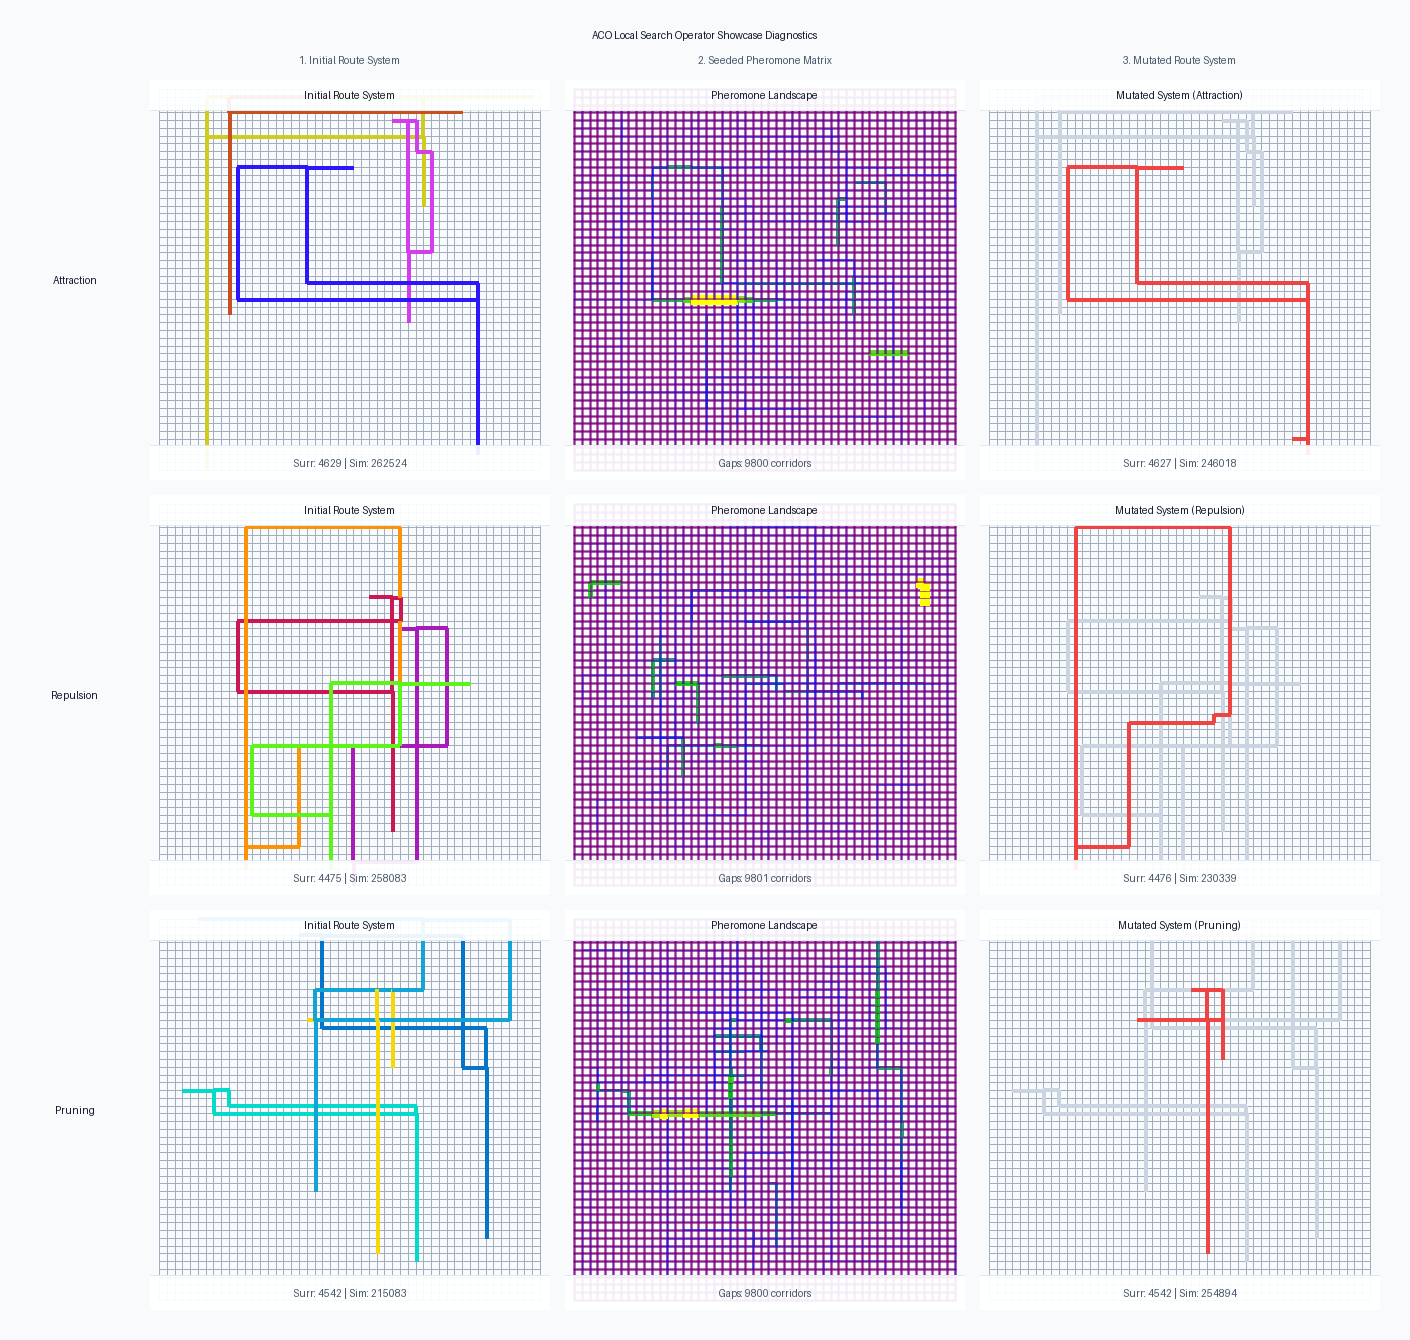

In [ ]:
# ==============================================================================
# ACO Local Search Diagnostics - Step 4: Stitching & Drawing the Showcase Dashboard
# ==============================================================================

CELL_SIZE = 400
COLS = 3
ROWS = 3
LEFT_MARGIN = 150
TOP_MARGIN = 80
SPACING = 15
RIGHT_MARGIN = 30
BOTTOM_MARGIN = 30

GRID_W = LEFT_MARGIN + COLS * CELL_SIZE + (COLS - 1) * SPACING + RIGHT_MARGIN
GRID_H = TOP_MARGIN + ROWS * CELL_SIZE + (ROWS - 1) * SPACING + BOTTOM_MARGIN

print(f"[DIAGNOSTIC DASHBOARD] Creating {GRID_W}x{GRID_H} light-themed showcase dashboard...")
grid_img = Image.new("RGB", (GRID_W, GRID_H), "#f8fafc")
draw = ImageDraw.Draw(grid_img)

# Try loading typography
try:
    font_title = ImageFont.truetype("segoeuib.ttf", 26)
    font_header = ImageFont.truetype("segoeuib.ttf", 20)
except IOError:
    try:
        font_title = ImageFont.truetype("arial.ttf", 26)
        font_header = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font_title = ImageFont.load_default()
        font_header = ImageFont.load_default()

# Draw main title
draw.text((GRID_W // 2, 35), "ACO Local Search Operator Showcase Diagnostics", fill="#0f172a", font=font_title, anchor="mm")

# Draw column headers
col_headers = [
    "1. Initial Route System",
    "2. Seeded Pheromone Matrix",
    "3. Mutated Route System"
]
for col in range(COLS):
    cx = LEFT_MARGIN + col * (CELL_SIZE + SPACING) + CELL_SIZE // 2
    draw.text((cx, TOP_MARGIN - 20), col_headers[col], fill="#475569", font=font_header, anchor="mm")

# Stitch the panels
row_labels = ["Attraction", "Repulsion", "Pruning"]
for row in range(ROWS):
    ry = TOP_MARGIN + row * (CELL_SIZE + SPACING)
    
    # Draw row label on the left margin
    draw.text((LEFT_MARGIN // 2, ry + CELL_SIZE // 2), row_labels[row], fill="#0f172a", font=font_header, anchor="mm")
    
    # Paste panels
    for col in range(COLS):
        grid_img.paste(showcase_panels[row][col], (LEFT_MARGIN + col * (CELL_SIZE + SPACING), ry))

print("[DIAGNOSTIC DASHBOARD] Showcase render complete. Visualizing below:")
display(grid_img)


#### Below is a quick statistical test to verify the effectiveness of our mutation methods scored via the StaticSurrogateEvaluator for speed. They have been commented out since they are outside of the "diagnostics" pipeline.

In [ ]:
"""
# ==========================================
# CONFIGURATION PARAMETERS
# ==========================================
K = 50                      # Minimum viable loop execution
N_ROUTES = [10]             # Restrict to a single baseline geometry
OPERATORS = ['attraction', 'repulsion', 'pruning']
INTENSITY = 2.0
NUM_SURROGATE_SAMPLES = 100 # Sufficient for stable surrogate scoring
ALPHA = 0.05
"""

"\n# ==========================================\n# CONFIGURATION PARAMETERS\n# ==========================================\nK = 50                      # Minimum viable loop execution\nN_ROUTES = [10]             # Restrict to a single baseline geometry\nOPERATORS = ['attraction', 'repulsion', 'pruning']\nINTENSITY = 2.0\nNUM_SURROGATE_SAMPLES = 100 # Sufficient for stable surrogate scoring\nALPHA = 0.05\n"

In [ ]:
"""
# ==========================================
# ENVIRONMENT AND STATISTICAL HELPERS
# ==========================================
from utils.toy_city import toy_setup_from_yaml
from utils.route import RouteGenerator, RouteSystem, Route
from utils.travel_graph import TravelGraph
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.passenger_generator import PassengerGenerator
from utils.simulation import Simulation, StaticSurrogateEvaluator
from utils.pheromone import PheromoneMatrix
from utils.local_search import ACOLocalSearch
import statistics
import math
from tqdm.auto import tqdm
from scipy.stats import wilcoxon

city, sampler, cfg = toy_setup_from_yaml('configs/toy_city_configs.yaml', verbose=False)

def run_sim_for_gaps(routes, city, sampler, cfg):
    # Executes a minimal simulation strictly to project fleet geometry for gap detection.
    sim_cfg = cfg['simulation']
    tg = TravelGraph(
        cg=city, config=cfg['travel_graph'],
        route_generator=None, routes=routes,
        n_routes=len(routes), n_points=4
    )
    jeeps = [
        Jeep(r, curr_pos=(r.path[0].start.lon, r.path[0].start.lat),
             speed=sim_cfg.get('jeep_speed_kmh', 20.0), max_capacity=16, seconds_per_tick=30)
        for r in routes for _ in range(5)
    ]
    jeep_sys = JeepSystem(jeeps=jeeps, routes=routes, weight_tolerance=50.0, equidistant_spawn=True)
    pax_gen  = PassengerGenerator(
        tg=tg, sampler=sampler,
        rate_per_hour=120.0, stdev=10.0, speed=4.5, seconds_per_tick=30
    )
    sim = Simulation(
        city_query=city.name, bounds=city.get_bounds(),
        jeep_system=jeep_sys, passenger_generator=pax_gen,
        max_ticks=50, beta_penalty=2.0, alpha_std_penalty=0.5, config=cfg
    )
    return sim.run()

def build_pheromones(routes, city, sampler, cfg, n_seed=15):
    result = run_sim_for_gaps(routes, city, sampler, cfg)
    pheromones = PheromoneMatrix(city.graph, cfg)
    for _ in range(n_seed):
        path = city.find_shortest_path(sampler.get_point(True), sampler.get_point(True))
        if path:
            for e in path:
                pheromones.tau[e] = pheromones.tau.get(e, 1.0) + 10.0
    pheromones.gaps = pheromones.calculate_demand_service_gaps(result.jeep_system)
    return pheromones

def wilcoxon_one_sided(deltas):
    # One-sided Wilcoxon signed-rank test.
    # H_A: mutated_metric < baseline_metric (median difference < 0).
    nonzero = [d for d in deltas if d != 0]
    if len(nonzero) < 12:
        return 1.0
    try:
        _, p = wilcoxon(nonzero, alternative='less')
        return p
    except ValueError:
        return 1.0

def calculate_route_length(route):
    return sum(e.getLength() for e in route.path)

def calculate_distance_to_edge(route, target_edge):
    t_start_lon, t_start_lat = target_edge.start.lon, target_edge.start.lat
    t_end_lon, t_end_lat = target_edge.end.lon, target_edge.end.lat
    
    dist_to_start = min(math.hypot(n.lon - t_start_lon, n.lat - t_start_lat) for e in route.path for n in (e.start, e.end))
    dist_to_end = min(math.hypot(n.lon - t_end_lon, n.lat - t_end_lat) for e in route.path for n in (e.start, e.end))
    
    return min(dist_to_start, dist_to_end)

def export_documentation_frame(city, original_routes, mutated_routes, operator_name):
    img = city.draw(size=800, only_drivable=True)
    context = city.get_bounds()
    
    rs_orig = RouteSystem()
    for r in original_routes:
        rs_orig.add_route(r)
    rs_orig.draw(context, img, line_width=2, dash_length=4)
    
    rs_mut = RouteSystem()
    for r in mutated_routes:
        rs_mut.add_route(r)
    rs_mut.draw(context, img, line_width=4, dash_length=0)
    
    img.save(f"utils/.cache/{operator_name}_mutation_doc.png")
"""

'\n# ==========================================\n# ENVIRONMENT AND STATISTICAL HELPERS\n# ==========================================\nfrom utils.toy_city import toy_setup_from_yaml\nfrom utils.route import RouteGenerator, RouteSystem, Route\nfrom utils.travel_graph import TravelGraph\nfrom utils.jeep import Jeep\nfrom utils.jeep_system import JeepSystem\nfrom utils.passenger_generator import PassengerGenerator\nfrom utils.simulation import Simulation, StaticSurrogateEvaluator\nfrom utils.pheromone import PheromoneMatrix\nfrom utils.local_search import ACOLocalSearch\nimport statistics\nimport math\nfrom tqdm.auto import tqdm\nfrom scipy.stats import wilcoxon\n\ncity, sampler, cfg = toy_setup_from_yaml(\'configs/toy_city_configs.yaml\', verbose=False)\n\ndef run_sim_for_gaps(routes, city, sampler, cfg):\n    # Executes a minimal simulation strictly to project fleet geometry for gap detection.\n    sim_cfg = cfg[\'simulation\']\n    tg = TravelGraph(\n        cg=city, config=cfg[\'travel

In [ ]:
"""
# ==========================================
# DATA COLLECTION AND EXECUTION LOOP
# ==========================================
# Store tuples of (global_delta, local_delta, fired: bool)

results = {op: {n: [] for n in N_ROUTES} for op in OPERATORS}
doc_captured = {op: False for op in OPERATORS}

generator = RouteGenerator(city_graph=city, sampler=sampler, verbose=False)
engine    = ACOLocalSearch(cg=city, p_local=1.0, base_window_size=15)
surrogate = StaticSurrogateEvaluator(config=cfg, city_graph=city, demand_sampler=sampler, num_samples=NUM_SURROGATE_SAMPLES)

for n_routes in N_ROUTES:
    print(f'\n[TRIAL] N_ROUTES={n_routes} — executing K={K} iterations')
    
    for trial in tqdm(range(K), desc=f"N={n_routes} Progress"):
        baseline_routes = [generator.generate(n_points=4) for _ in range(n_routes)]
        pheromones = build_pheromones(baseline_routes, city, sampler, cfg)

        base_res = surrogate.evaluate(baseline_routes)
        base_cost_ar = base_res.fitness_score
        base_pax = base_res.metrics["passenger_routing_cost"]
        base_fleet = base_res.metrics["fleet_operational_cost"]
        base_cost_prune = 2.0

        # --- Attraction ---
        from utils.pheromone import _edge_key
        routes_attr = [Route(city_graph=city, path=r.path[:]) for r in baseline_routes]
        underserved_keys = {_edge_key(e) for e, g in pheromones.gaps.items() if g > 0}
        base_route_keys = {_edge_key(e) for r in baseline_routes for e in r.path}
        base_us_covered = len(underserved_keys & base_route_keys)
        base_unique_attr = len(base_route_keys)

        fired = engine.strategy_spatial_attraction(routes_attr, pheromones, intensity=INTENSITY) is not None
        if fired:
            mut_route_keys = {_edge_key(e) for r in routes_attr for e in r.path}
            mut_us_covered = len(underserved_keys & mut_route_keys)
            local_delta_attr = -(mut_us_covered - base_us_covered)  # negative = more underserved coverage
            global_delta_attr = -(len(mut_route_keys) - base_unique_attr)  # negative = more diversity
            results['attraction'][n_routes].append((global_delta_attr, local_delta_attr, True))
            if not doc_captured['attraction']:
                export_documentation_frame(city, baseline_routes, routes_attr, "attraction")
                doc_captured['attraction'] = True
        else:
            results['attraction'][n_routes].append((0.0, 0.0, False))

        # --- Repulsion ---
        routes_rep = [Route(city_graph=city, path=r.path[:]) for r in baseline_routes]
        forced_edge = routes_rep[0].path[len(routes_rep[0].path) // 2]
        forced_id   = engine._edge_id(forced_edge)

        if not any(engine._edge_id(e) == forced_id for e in routes_rep[-1].path):
            spliced = engine._safe_splice(routes_rep[-1].path, 0, 1, [forced_edge])
            if spliced:
                from utils.directed_edge import DirEdge
                l2_spliced = []
                for edge in spliced:
                    l2_edge = DirEdge(edge.start, edge.end, weight=edge.weight)
                    setattr(l2_edge, 'layer', 2)
                    l2_spliced.append(l2_edge)
                for i in range(len(l2_spliced)):
                    l2_spliced[i].next_edges.append(l2_spliced[(i + 1) % len(l2_spliced)])
                routes_rep[-1].path = l2_spliced

        base_overlap = sum(1 for r in routes_rep for e in r.path if engine._edge_id(e) == forced_id)

        # Temporarily inject the forced overservice signal, restore after.
        original_gaps = pheromones.gaps
        pheromones.gaps = {**original_gaps, forced_edge: -500.0}
        fired = engine.strategy_redundancy_repulsion(routes_rep, pheromones, intensity=INTENSITY) is not None
        pheromones.gaps = original_gaps

        if fired:
            base_unique = len({engine._edge_id(e) for r in baseline_routes for e in r.path})
            mut_unique  = len({engine._edge_id(e) for r in routes_rep for e in r.path})
            global_delta_rep = -(mut_unique - base_unique)  # negative = more diversity = good
            mut_overlap = sum(1 for r in routes_rep for e in r.path if engine._edge_id(e) == forced_id)
            results['repulsion'][n_routes].append((global_delta_rep, mut_overlap - base_overlap, True))
            if not doc_captured['repulsion']:
                export_documentation_frame(city, baseline_routes, routes_rep, "repulsion")
                doc_captured['repulsion'] = True
        else:
            results['repulsion'][n_routes].append((0.0, 0.0, False))

        # --- Pruning ---
        routes_prune = [Route(city_graph=city, path=r.path[:]) for r in baseline_routes]
        base_length  = sum(calculate_route_length(r) for r in baseline_routes)

        prune_count, _ = engine.strategy_tortuosity_pruning(routes_prune, pheromones, intensity=INTENSITY)
        if prune_count > 0:
            mut_res   = surrogate.evaluate(routes_prune)
            mut_pax   = mut_res.metrics["passenger_routing_cost"]
            mut_fleet = mut_res.metrics["fleet_operational_cost"]
            mut_cost  = (mut_pax / max(1.0, base_pax)) + (mut_fleet / max(1.0, base_fleet))
            mut_length = sum(calculate_route_length(r) for r in routes_prune)
            results['pruning'][n_routes].append((mut_cost - base_cost_prune, mut_length - base_length, True))
            if not doc_captured['pruning']:
                export_documentation_frame(city, baseline_routes, routes_prune, "pruning")
                doc_captured['pruning'] = True
        else:
            results['pruning'][n_routes].append((0.0, 0.0, False))

print('\n[TRIAL] Data collection complete. Image frames generated in cache.')
"""

'\n# ==========================================\n# DATA COLLECTION AND EXECUTION LOOP\n# ==========================================\n# Store tuples of (global_delta, local_delta, fired: bool)\n\nresults = {op: {n: [] for n in N_ROUTES} for op in OPERATORS}\ndoc_captured = {op: False for op in OPERATORS}\n\ngenerator = RouteGenerator(city_graph=city, sampler=sampler, verbose=False)\nengine    = ACOLocalSearch(cg=city, p_local=1.0, base_window_size=15)\nsurrogate = StaticSurrogateEvaluator(config=cfg, city_graph=city, demand_sampler=sampler, num_samples=NUM_SURROGATE_SAMPLES)\n\nfor n_routes in N_ROUTES:\n    print(f\'\n[TRIAL] N_ROUTES={n_routes} — executing K={K} iterations\')\n\n    for trial in tqdm(range(K), desc=f"N={n_routes} Progress"):\n        baseline_routes = [generator.generate(n_points=4) for _ in range(n_routes)]\n        pheromones = build_pheromones(baseline_routes, city, sampler, cfg)\n\n        base_res = surrogate.evaluate(baseline_routes)\n        base_cost_ar = base

In [ ]:
"""
# ==========================================
# METRIC ANALYSIS
# ==========================================
print('\n' + '=' * 115)
print(f'  DUAL-METRIC STATISTICAL SUMMARY  (K={K}, One-Sided Wilcoxon)')
print('=' * 115)

for op in OPERATORS:
    print(f'\n  [{op.upper()}]')
    print(f'  {"N":<4} {"Fired":<6} | {"L.Delta":<10} {"L.Win%":<7} {"L.p":<7} {"L.Stat":<10} | {"G.Delta":<10} {"G.Win%":<7} {"G.p":<7} {"G.Stat"}')
    print('  ' + '-' * 110)

    for n in N_ROUTES:
        trials = results[op][n]
        fired_trials  = [(g, l) for g, l, f in trials if f]
        fire_rate     = len(fired_trials) / len(trials) if trials else 0.0

        if not fired_trials:
            print(f'  {n:<4} {f"{fire_rate:.0%}":<6} | {"N/A":<10} {"N/A":<7} {"N/A":<7} {"NEVER FIRED":<10} | {"N/A":<10} {"N/A":<7} {"N/A":<7} NEVER FIRED')
            continue

        global_deltas = [g for g, _ in fired_trials]
        local_deltas  = [l for _, l in fired_trials]
        
        med_global = statistics.median(global_deltas)
        med_local  = statistics.median(local_deltas)
        
        p_global = wilcoxon_one_sided(global_deltas)
        p_local  = wilcoxon_one_sided(local_deltas)
        
        loc_win_pct = sum(1 for d in local_deltas if d < 0) / len(local_deltas)
        glob_win_pct = sum(1 for d in global_deltas if d < 0) / len(global_deltas)

        def eval_status(med, p):
            if med < 0 and p < ALPHA: return "VALIDATED"
            if med < 0: return "TREND"
            return "FAIL"

        stat_loc = eval_status(med_local, p_local)
        stat_glob = eval_status(med_global, p_global)

        print(f'  {n:<4} {f"{fire_rate:.0%}":<6} | {med_local:<10.2f} {f"{loc_win_pct:.0%}":<7} {p_local:<7.3f} {stat_loc:<10} | {med_global:<10.1f} {f"{glob_win_pct:.0%}":<7} {p_global:<7.3f} {stat_glob}')
"""

'\n# ==========================================\n# METRIC ANALYSIS\n# ==========================================\nprint(\'\n\' + \'=\' * 115)\nprint(f\'  DUAL-METRIC STATISTICAL SUMMARY  (K={K}, One-Sided Wilcoxon)\')\nprint(\'=\' * 115)\n\nfor op in OPERATORS:\n    print(f\'\n  [{op.upper()}]\')\n    print(f\'  {"N":<4} {"Fired":<6} | {"L.Delta":<10} {"L.Win%":<7} {"L.p":<7} {"L.Stat":<10} | {"G.Delta":<10} {"G.Win%":<7} {"G.p":<7} {"G.Stat"}\')\n    print(\'  \' + \'-\' * 110)\n\n    for n in N_ROUTES:\n        trials = results[op][n]\n        fired_trials  = [(g, l) for g, l, f in trials if f]\n        fire_rate     = len(fired_trials) / len(trials) if trials else 0.0\n\n        if not fired_trials:\n            print(f\'  {n:<4} {f"{fire_rate:.0%}":<6} | {"N/A":<10} {"N/A":<7} {"N/A":<7} {"NEVER FIRED":<10} | {"N/A":<10} {"N/A":<7} {"N/A":<7} NEVER FIRED\')\n            continue\n\n        global_deltas = [g for g, _ in fired_trials]\n        local_deltas  = [l for _, l in fired_tr

### Dual-Metric Statistical Summary
**Parameters:** $K = 50$, One-Sided Wilcoxon Signed-Rank Test

| Phase | N | Fired | L.Delta | L.Win% | L.p-value | L.Stat | G.Delta | G.Win% | G.p-value | G.Stat |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Attraction** | 10 | 100% | -6.00 | 100% | 0.000 | VALIDATED | -6.0 | 100% | 0.000 | VALIDATED |
| **Repulsion** | 10 | 94% | -1.00 | 100% | 0.000 | VALIDATED | -35.0 | 94% | 0.000 | VALIDATED |
| **Pruning** | 10 | 100% | -1000.76 | 100% | 0.000 | VALIDATED | -0.0 | 96% | 0.000 | VALIDATED |